# Stacking, Evaluation & SHAP and import

In [1]:
import numpy as np
import pandas as pd
import joblib
import shap               # Explains WHY a prediction was made
import matplotlib.pyplot as plt
import warnings, torch
warnings.filterwarnings('ignore')

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (classification_report, confusion_matrix,
                             precision_recall_curve, roc_auc_score,
                             average_precision_score, ConfusionMatrixDisplay)
import xgboost as xgb
import torch.nn as nn

# Redefine autoencoder class (must match NB3 definition exactly)
class FraudAutoencoder(nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 32), nn.ReLU(), nn.Dropout(0.2),
            nn.Linear(32, 16), nn.ReLU(), nn.Linear(16, 8))
        self.decoder = nn.Sequential(
            nn.Linear(8, 16), nn.ReLU(),
            nn.Linear(16, 32), nn.ReLU(), nn.Linear(32, input_dim))
    def forward(self, x):
        return self.decoder(self.encoder(x))

device = torch.device('cpu')
print(' Imports done!')

 Imports done!


In [2]:
!python -m pip install shap

Defaulting to user installation because normal site-packages is not writeable
  Using cached shap-0.51.0-cp313-cp313-win_amd64.whl.metadata (26 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
Using cached shap-0.51.0-cp313-cp313-win_amd64.whl (555 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
   ---------------------------------------- 0.0/12.6 MB ? eta -:--:--
   - -------------------------------------- 0.5/12.6 MB 3.3 MB/s eta 0:00:04
   ---- ----------------------------------- 1.3/12.6 MB 3.3 MB/s eta 0:00:04
   ----- ---------------------------------- 1.8/12.6 MB 3.2 MB/s eta 0:00:04
   ------- -------------------------------- 2.4/12.6 MB 2.8 MB/s eta 0:00:04
   ---------- ----------------------------- 3.1/12.6 MB 3.1 MB/s eta 0:00:04
   ---------- ----------------------------- 3.1/12.6 MB 3.1 MB/s eta 0:00:04
   ------------- -------------------------- 4.2/12.6 MB 2.9 MB/s eta 0:00:03
   --------------- ------------------------ 4.7/12.6 MB 2.8 MB/s eta 

  Consider adding this directory to PATH or, if you prefer to suppress this warning, use --no-warn-script-location.
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dtale 3.18.2 requires scipy!=1.12.0rc1,!=1.14.0,!=1.14.0rc1,!=1.14.0rc2,<1.16.0; python_version >= "3.10", but you have scipy 1.17.0 which is incompatible.
mlxtend 0.24.0 requires numpy>=2.3.5, but you have numpy 2.1.3 which is incompatible.


# Load all models and data

In [2]:
data      = joblib.load('../models/data_splits.pkl')
lr_model  = joblib.load('../models/logistic_regression.pkl')
rf_model  = joblib.load('../models/random_forest.pkl')
xgb_model = joblib.load('../models/xgboost.pkl')
iso_model = joblib.load('../models/isolation_forest.pkl')
ae_cfg    = joblib.load('../models/autoencoder_config.pkl')

ae_model  = FraudAutoencoder(ae_cfg['input_dim'])
ae_model.load_state_dict(
    torch.load('../models/autoencoder.pt', map_location=device))
ae_model.eval()

X_val, y_val   = data['X_val'], data['y_val']
X_test, y_test = data['X_test'], data['y_test']
feature_names  = data['feature_names']

print(' All models and data loaded!')

 All models and data loaded!


# Helper function for autoencoder scores

In [3]:
def get_ae_scores(model, X):
    # Computes reconstruction error for each row
    # Higher error = more anomalous = likely fraud
    model.eval()
    with torch.no_grad():
        t   = torch.FloatTensor(X.values)
        err = ((t - model(t)) ** 2).mean(dim=1).numpy()
    return err

#  Build stacking features

In [4]:
def get_stack_features(X, lr, rf, xgb_m, iso, ae):
    # Creates a matrix where each column = one model's fraud score
    # Meta-learner will learn how to combine these 5 scores
    lr_scores  = lr.predict_proba(X)[:, 1]
    rf_scores  = rf.predict_proba(X)[:, 1]
    xgb_scores = xgb_m.predict_proba(X)[:, 1]
    iso_scores = -iso.score_samples(X)      # Negate so higher = more fraud
    ae_scores  = get_ae_scores(ae, X)

    # column_stack: combines 5 arrays into one (N rows × 5 cols) matrix
    return np.column_stack([lr_scores, rf_scores,
                            xgb_scores, iso_scores, ae_scores])

print('Building stacking features for validation set...')
X_val_stack = get_stack_features(
    X_val, lr_model, rf_model, xgb_model, iso_model, ae_model)

print(f'Stacking matrix shape: {X_val_stack.shape}')
print('Columns: [LR, RF, XGB, IsolationForest, Autoencoder]')

Building stacking features for validation set...
Stacking matrix shape: (28481, 5)
Columns: [LR, RF, XGB, IsolationForest, Autoencoder]


#  Train meta-learner

In [5]:
# Meta-learner = Logistic Regression that learns optimal weights for each model
# Trains on validation set stacking features
meta_model = LogisticRegression(
    C=1.0,
    class_weight='balanced',
    random_state=42
)
meta_model.fit(X_val_stack, y_val)

# Print what weights meta-learner assigned each model
model_names = ['Logistic Reg', 'Random Forest', 'XGBoost',
               'Isolation Forest', 'Autoencoder']
weights = meta_model.coef_[0]

print('Meta-learner weights (higher = more trusted):')
for name, w in zip(model_names, weights):
    print(f'  {name:20s}: {w:+.4f}')

joblib.dump(meta_model, '../models/meta_learner.pkl')
print('\n Meta-learner saved!')

Meta-learner weights (higher = more trusted):
  Logistic Reg        : -0.4624
  Random Forest       : +12.2211
  XGBoost             : +7.3161
  Isolation Forest    : +10.4821
  Autoencoder         : +0.1131

 Meta-learner saved!


#  Test set evaluation

In [6]:
# NEVER look at test set during training — only here at the very end!
print('Evaluating on TEST set...')
X_test_stack = get_stack_features(
    X_test, lr_model, rf_model, xgb_model, iso_model, ae_model)

# Final fraud probability from meta-learner
final_proba = meta_model.predict_proba(X_test_stack)[:, 1]

# Convert probability to 0/1 using threshold
THRESHOLD   = 0.35   # Lower = catch more fraud (higher recall)
final_preds = (final_proba >= THRESHOLD).astype(int)

print(f'\n=== TEST SET RESULTS (threshold = {THRESHOLD}) ===')
print(classification_report(y_test, final_preds,
                             target_names=['Legit', 'Fraud']))
print(f'PR-AUC  : {average_precision_score(y_test, final_proba):.4f}')
print(f'ROC-AUC : {roc_auc_score(y_test, final_proba):.4f}')

Evaluating on TEST set...

=== TEST SET RESULTS (threshold = 0.35) ===
              precision    recall  f1-score   support

       Legit       1.00      0.97      0.98     56864
       Fraud       0.04      0.91      0.08        98

    accuracy                           0.97     56962
   macro avg       0.52      0.94      0.53     56962
weighted avg       1.00      0.97      0.98     56962

PR-AUC  : 0.7652
ROC-AUC : 0.9744


# Confusion matrix

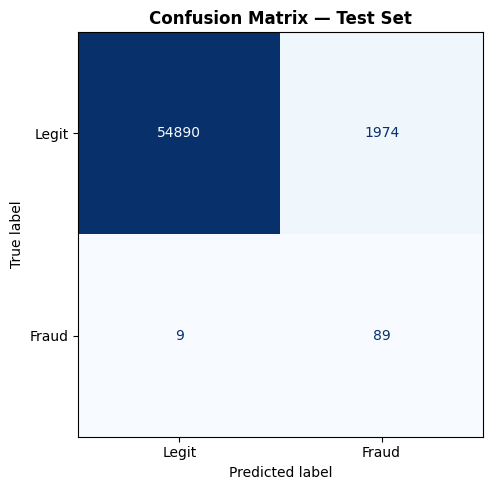

Fraud caught  (TP): 89  ✅
Fraud missed  (FN): 9  ❌
Legit blocked (FP): 1974  ⚠️
Legit approved(TN): 54890  ✅


In [8]:
import os
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, final_preds)

fig, ax = plt.subplots(figsize=(6,5))
ConfusionMatrixDisplay(cm, display_labels=['Legit','Fraud']).plot(
    ax=ax, colorbar=False, cmap='Blues'
)

ax.set_title('Confusion Matrix — Test Set', fontweight='bold')
plt.tight_layout()

# create folder if it doesn't exist
os.makedirs('../data', exist_ok=True)

plt.savefig('../data/confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

tn, fp, fn, tp = cm.ravel()

print(f'Fraud caught  (TP): {tp}  ✅')
print(f'Fraud missed  (FN): {fn}  ❌')
print(f'Legit blocked (FP): {fp}  ⚠️')
print(f'Legit approved(TN): {tn}  ✅')

# Precision-Recall curve

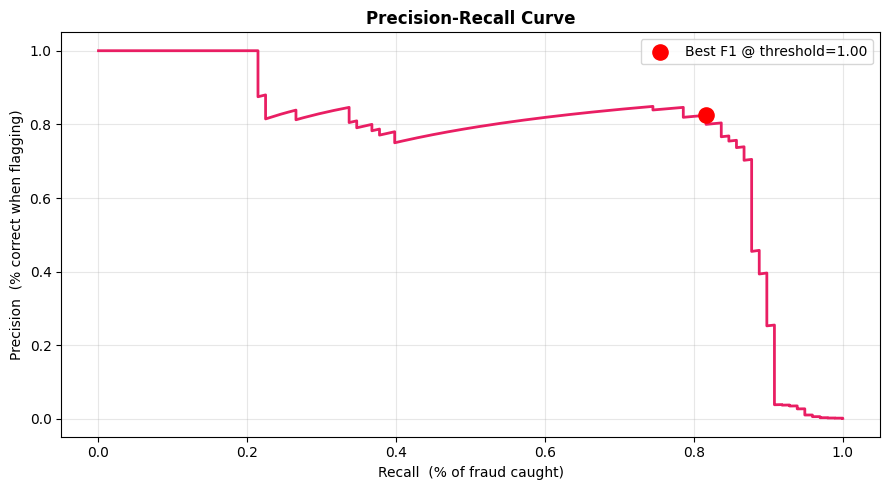

Best threshold for F1: 1.000


In [9]:
# Shows tradeoff between precision and recall at every threshold
# Helps choose the best threshold for your business needs
precision, recall, thresholds = precision_recall_curve(y_test, final_proba)

# F1 = harmonic mean of precision and recall
# Best threshold = where F1 is highest
f1_scores  = 2 * precision * recall / (precision + recall + 1e-9)
best_idx   = f1_scores.argmax()
best_thresh = thresholds[best_idx] if best_idx < len(thresholds) else 0.5

plt.figure(figsize=(9, 5))
plt.plot(recall, precision, color='#E91E63', linewidth=2)
plt.scatter(recall[best_idx], precision[best_idx],
            s=120, color='red', zorder=5,
            label=f'Best F1 @ threshold={best_thresh:.2f}')
plt.xlabel('Recall  (% of fraud caught)')
plt.ylabel('Precision  (% correct when flagging)')
plt.title('Precision-Recall Curve', fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig('../data/pr_curve.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Best threshold for F1: {best_thresh:.3f}')

# SHAP feature importance

Computing SHAP values... (1-2 min)


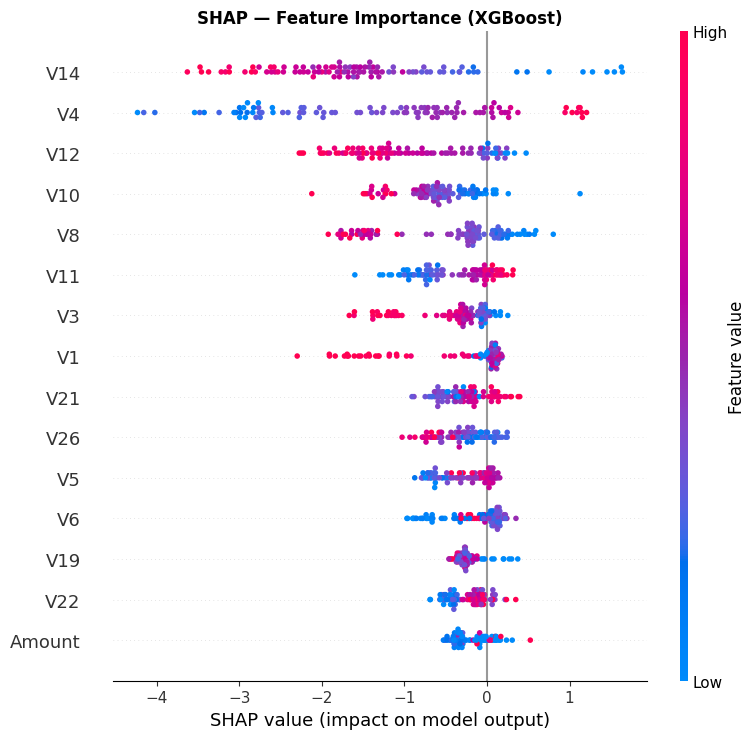

💡 Top features = most important for detecting fraud


In [10]:
# SHAP explains: WHY did XGBoost predict fraud for this transaction?
# Each feature gets a score: positive = pushes toward fraud, negative = toward legit
print('Computing SHAP values... (1-2 min)')

explainer   = shap.TreeExplainer(xgb_model)
X_sample    = X_test.iloc[:100]     # Use 100 rows for speed
shap_values = explainer.shap_values(X_sample)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_sample,
                  feature_names=feature_names,
                  show=False, max_display=15)
plt.title('SHAP — Feature Importance (XGBoost)', fontweight='bold')
plt.tight_layout()
plt.savefig('../data/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print('💡 Top features = most important for detecting fraud')

#  Save config and finish

In [11]:
joblib.dump({
    'threshold'    : float(best_thresh),
    'feature_names': feature_names
}, '../models/prediction_config.pkl')

print(' Evaluation complete!')
print(' Prediction config saved to models/prediction_config.pkl')
print('  Now open NB5!')

 Evaluation complete!
 Prediction config saved to models/prediction_config.pkl
  Now open NB5!


In [12]:
import os

# Check all required model files exist
models_needed = [
    'scaler.pkl',
    'logistic_regression.pkl',
    'random_forest.pkl',
    'xgboost.pkl',
    'isolation_forest.pkl',
    'autoencoder.pt',
    'autoencoder_config.pkl',
    'meta_learner.pkl',
    'prediction_config.pkl',
    'data_splits.pkl'
]

print('Checking model files...')
all_good = True
for f in models_needed:
    path   = f'../models/{f}'
    exists = os.path.exists(path)
    status = '' if exists else ' MISSING'
    print(f'  {status}  {f}')
    if not exists:
        all_good = False

print()
if all_good:
    print(' All files present — ready for NB5!')
else:
    print('  Some files missing — re-run the notebook that saves them')

Checking model files...
    scaler.pkl
    logistic_regression.pkl
    random_forest.pkl
    xgboost.pkl
    isolation_forest.pkl
    autoencoder.pt
    autoencoder_config.pkl
    meta_learner.pkl
    prediction_config.pkl
    data_splits.pkl

 All files present — ready for NB5!
